In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("mtsamples.csv.zip")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Shape: (4999, 6)

Columns:
Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [3]:
print(df.isnull().sum())

Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [4]:
df = df.dropna(subset=["transcription"])

print("New Shape:", df.shape)

New Shape: (4966, 6)


In [5]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("New Shape:", df.shape)

Duplicates: 0
New Shape: (4966, 6)


In [6]:
def remove_phi(text):

    text = str(text)

    # Remove emails
    text = re.sub(r'\S+@\S+', '[EMAIL]', text)

    # Remove dates
    text = re.sub(
        r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}',
        '[DATE]',
        text
    )

    # Remove phone numbers
    text = re.sub(
        r'\b\d{10}\b',
        '[PHONE]',
        text
    )

    return text

In [7]:
df["text_no_phi"] = df["transcription"].apply(remove_phi)

In [8]:
def clean_text(text):

    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [9]:
df["clean_text"] = df["text_no_phi"].apply(clean_text)

print(df["clean_text"].iloc[0][:500])

subjective this year old white female presents with complaint of allergies she used to have allergies when she lived in seattle but she thinks they are worse here in the past she has tried claritin and zyrtec both worked for short time but then seemed to lose effectiveness she has used allegra also she used that last summer and she began using it again two weeks ago it does not appear to be working very well she has used over the counter sprays but no prescription nasal sprays she does have asth


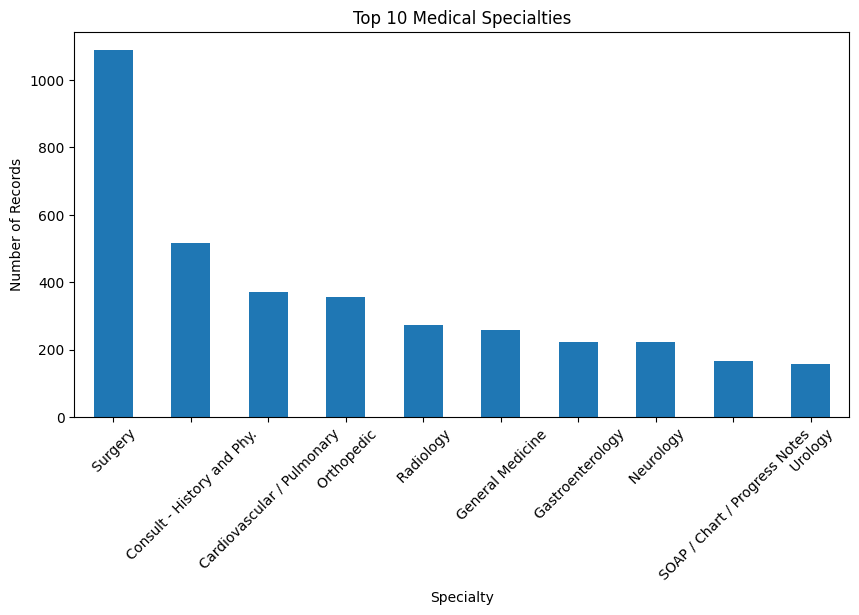

In [10]:
df["medical_specialty"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Medical Specialties")

plt.xlabel("Specialty")

plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.show()

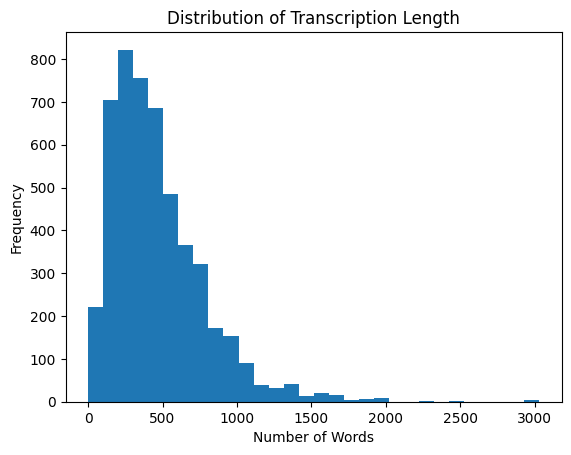

In [11]:
df["text_length"] = df["clean_text"].apply(
    lambda x: len(x.split())
)

plt.hist(
    df["text_length"],
    bins=30
)

plt.title("Distribution of Transcription Length")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

In [12]:
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

X_tfidf = tfidf.fit_transform(
    df["clean_text"]
)

print(
    "TF-IDF Shape:",
    X_tfidf.shape
)

TF-IDF Shape: (4966, 1000)


In [13]:
!pip install transformers -q

In [14]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [15]:
tokens = tokenizer(
    df["clean_text"].iloc[0],
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

print(tokens)

{'input_ids': tensor([[  101, 20714,  2023,  2095,  2214,  2317,  2931,  7534,  2007, 12087,
          1997,  2035,  2121, 17252,  2016,  2109,  2000,  2031,  2035,  2121,
         17252,  2043,  2016,  2973,  1999,  5862,  2021,  2016,  6732,  2027,
          2024,  4788,  2182,  1999,  1996,  2627,  2016,  2038,  2699, 18856,
          8486,  7629,  1998,  1062, 12541, 26557,  2119,  2499,  2005,  2460,
          2051,  2021,  2059,  2790,  2000,  4558, 12353,  2016,  2038,  2109,
          2035, 13910,  2527,  2036,  2016,  2109,  2008,  2197,  2621,  1998,
          2016,  2211,  2478,  2009,  2153,  2048,  3134,  3283,  2009,  2515,
          2025,  3711,  2000,  2022,  2551,  2200,  2092,  2016,  2038,  2109,
          2058,  1996,  4675, 12509,  2015,  2021,  2053, 20422, 19077, 12509,
          2015,  2016,  2515,  2031, 26180,  2021,  2515,  2102,  2025,  5478,
          3679, 14667,  2005,  2023,  1998,  2515,  2025,  2228,  2009,  2003,
         13109, 22397,  2039, 20992,  